In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# **Data Loading and Preprocessing**

In [ ]:
df_cams = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/TFG/data/CAMS.parquet')
df_cams

,time,hour_fraction,irradiancia_W_m2,irradiancia_30_grados,irradiancia_90_grados
0,2025-09-21 02:00:30,2.008333,0.0,0.0,0.0
1,2025-09-21 02:01:30,2.025000,0.0,0.0,0.0
2,2025-09-21 02:02:30,2.041667,0.0,0.0,0.0
3,2025-09-21 02:03:30,2.058333,0.0,0.0,0.0
4,2025-09-21 02:04:30,2.075000,0.0,0.0,0.0
...,...,...,...,...,...
73435,2025-11-11 00:55:30,0.925000,0.0,0.0,0.0
73436,2025-11-11 00:56:30,0.941667,0.0,0.0,0.0
73437,2025-11-11 00:57:30,0.958333,0.0,0.0,0.0
73438,2025-11-11 00:58:30,0.975000,0.0,0.0,0.0


In [ ]:
def analyze_mpp_efficiency(cell_id, clean):
    # --- 1. Configuration & Data Loading ---
    path_cams = '/content/drive/MyDrive/Colab Notebooks/TFG/data/CAMS.parquet'
    if cell_id=='M0':
      path_mpp = '/content/drive/MyDrive/Colab Notebooks/TFG/data/M0/MPP_interp.parquet'
    elif cell_id=='P12':
      path_mpp = '/content/drive/MyDrive/Colab Notebooks/TFG/data/P12/MPP_interp.parquet'
    else:
      print('[ERROR] cell not found')
      return

    df_cams = pd.read_parquet(path_cams)
    print(df_cams)
    df_mpp = pd.read_parquet(path_mpp)

    # Preprocessing MPP & CAMS

    df_mpp['time'] = pd.to_datetime(df_mpp['time'])
    df_mpp.set_index('time', inplace=True)

    df_cams['time'] = pd.to_datetime(df_cams['time'])
    df_cams.set_index('time', inplace=True)
    df_cams.rename(columns={'irradiancia_30_grados':'irradiance_30_degrees'}, inplace=True)
    df_cams = df_cams[df_cams.index >= df_mpp.index[0]]

    if clean:
        df = pd.merge_asof(df_mpp.sort_index(), df_cams.sort_index(), on='time', tolerance=pd.Timedelta('1s'))
        df.set_index('time', inplace=True)
        df.index = pd.to_datetime(df.index)
        df = df.bfill().ffill()
        df.loc[df['irradiance_30_degrees'] == 0, 'power'] = 0

    # --- 1. Daily Energy Received (kWh/m²) ---
    # Irradiance (W/m²). Sampling: 1 min.
    # Sum W/m² * 1 min / (60 min/h * 1000 W/kW) -> kWh/m²

    daily_received = df_cams['irradiance_30_degrees'].resample('D').sum() / (60 * 1000)
    daily_received = daily_received[daily_received > 0]

    plt.figure(figsize=(16, 6))
    # Using dt.strftime to make the X-axis legible in the barplot
    ax = sns.barplot(x=daily_received.index.strftime('%Y-%m-%d'),
                y=daily_received.values,
                color='orange',
                alpha=0.8,
                edgecolor='black',
                linewidth=0.5)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Daily energy received (kWh/m²)', fontsize=14)
    plt.title(f'Daily Solar Energy Received – 30° Tilt', fontsize=20, fontweight='bold', pad=15)

    # Define the step (every 7 days)
    step = 7
    plt.xticks(ticks=range(0, len(daily_received), step), labels=daily_received.index[::step].strftime('%Y-%m-%d'), ha='center', fontsize=14)

    # Add ticks
    ax.tick_params(axis='x', which='major', bottom=True, length=5, width=1, colors='black')

    plt.yticks(fontsize=14)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- 2. Energy Produced (kWh) ---
    # Input: Power (W/m²). Sampling: 1 s.
    # Sum W/m² * 1 s / (3600 s/h * 10^6 mW/kW * 10^-4 m²/cm²) -> kWh/m²

    if clean:
      daily_produced = df['power'].resample('D').sum() / (3600 * 100)
    else:
      daily_produced = df_mpp['power'].resample('D').sum() / (3600 * 100)

    daily_produced = daily_produced[daily_produced > 0]

    # Plot Produced
    plt.figure(figsize=(16, 6))
    ax = sns.barplot(x=daily_produced.index.strftime('%Y-%m-%d'),
                y=daily_produced.values,
                color='green',
                alpha=0.8,
                edgecolor='black',
                linewidth=0.5)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Daily energy produced (kWh/m²)', fontsize=14)
    plt.title(f'Daily Produced Energy ({cell_id})', fontsize=20, fontweight='bold', pad=15)

    # Define the step (every 7 days)
    step = 7
    plt.xticks(ticks=range(0, len(daily_produced), step), labels=daily_produced.index[::step].strftime('%Y-%m-%d'), ha='center', fontsize=12)

    # Add ticks
    ax.tick_params(axis='x', which='major', bottom=True, length=5, width=1, colors='black')

    plt.yticks(fontsize=14)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- 4. Efficiency (%) ---
    # Formula: (Produced / Received) * 100

    # Align indices to ensure we divide the same days. (Pandas does this automatically, but this prevents errors if days are missing in one)
    aligned_produced, aligned_received = daily_produced.align(daily_received, join='inner')

    eff = (aligned_produced / aligned_received) * 100

    # Cleaning: Drop NaNs and Infinite values
    eff = eff.replace([np.inf, -np.inf], np.nan).dropna()

    # Plot Efficiency
    plt.figure(figsize=(16, 6))
    ax = sns.barplot(x=eff.index.strftime('%Y-%m-%d'),
                y=eff.values,
                color='steelblue',
                alpha=0.8,
                edgecolor='black',
                linewidth=0.5)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Efficiency (%)', fontsize=14)
    plt.title(f'Conversion Efficiency ({cell_id})', fontsize=20, fontweight='bold', pad=15)

    # Define the step (every 7 days)
    step = 7
    plt.xticks(ticks=range(0, len(eff), step), labels=eff.index[::step].strftime('%Y-%m-%d'), ha='center', fontsize=12)

    # Add ticks
    ax.tick_params(axis='x', which='major', bottom=True, length=5, width=1, colors='black')

    plt.yticks(fontsize=14)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- 5. Top 4 Curves ---

    df['irradiance_30_degrees'] = df['irradiance_30_degrees'].copy() * 1000 / 10000 # W/m2 -> mW/cm2
    df = df.rename(columns={'irradiance_30_degrees' : 'irradiance_30_degrees_mwcm2'}).copy()

    df_cams['irradiance_30_degrees'] = df_cams['irradiance_30_degrees'].copy() * 1000 / 10000 # W/m2 -> mW/cm2
    df_cams = df_cams.rename(columns={'irradiance_30_degrees' : 'irradiance_30_degrees_mwcm2'}).copy()

    # Sort efficiency to get the best days
    eff_best = eff.sort_values(ascending=False)

    # --- 2. Visualization ---
    fig, axs = plt.subplots(2, 2, figsize=(16, 14))
    fig.suptitle(f'Performance Analysis - Cell {cell_id}', fontsize=24, fontweight='bold', y=1.02)

    indices_to_plot = [0, 1, 2, 3]

    for k, ax in zip(indices_to_plot, axs.ravel()):
        # Get the date for the k-th best efficiency day
        target_date = eff_best.index[k].date()

        # Filter CAMS for the day and time range (06:00 - 22:00)
        if clean:
          day_cams = df[df.index.date == target_date]
        else:
          day_cams = df_cams[df_cams.index.date == target_date]
        day_cams = day_cams.between_time('06:00', '22:00').copy()

        # Filter PP for the day and time range
        if clean:
          day_pp = df[df.index.date == target_date]
        else:
          day_pp = df_mpp[df_mpp.index.date == target_date]
        day_pp = day_pp.between_time('06:00', '22:00').copy()

        # Re-format index to generic datetime for consistent plotting on the X-axis
        # (This avoids issues with specific dates and focuses on time)
        day_cams.index = pd.to_datetime(day_cams.index.strftime('%H:%M:%S'), format='%H:%M:%S')
        day_pp.index = pd.to_datetime(day_pp.index.strftime('%H:%M:%S'), format='%H:%M:%S')

        # --- Plotting ---
        sns.set_style("white")

        # Axis 1: Irradiance
        ax1 = ax
        sns.lineplot(
            x=day_cams.index,
            y=day_cams['irradiance_30_degrees_mwcm2'],
            linewidth=2.8,
            linestyle='--',
            color='darkorange',
            label='Irradiance (mW/cm²)',
            ax=ax1,
            errorbar=None
        )

        ax1.set_xlabel('Time of day', fontsize=14)
        ax1.set_ylabel('Irradiance (mW/cm²)', color='darkorange', fontsize=14)
        ax1.tick_params(axis='y', labelcolor='darkorange', labelsize=14)

        # Axis 2: Power Produced (Twin axis)
        ax2 = ax1.twinx()
        sns.lineplot(
            x=day_pp.index,
            y=day_pp['power'],
            color='forestgreen',
            linewidth=2,
            label='Produced Power (mW/cm²)',
            ax=ax2
        )

        ax2.set_ylabel('Produced Power (mW/cm²)', color='forestgreen', fontsize=14)
        ax2.tick_params(axis='y', labelcolor='forestgreen', labelsize=14)

        # Title and Formatting
        ax1.set_title(f'TOP # {k+1}: {target_date} - Efficiency: {eff_best.iloc[k]:.3f}%',
                      fontsize=16, fontweight='bold')

        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax1.tick_params(axis='x', labelsize=14)

        # Sync X-axis limits
        if not day_pp.empty:
            ax1.set_xlim([day_pp.index[0], day_pp.index[-1]])

        ax1.grid(True, linestyle='--', alpha=0.6)

        # Legends
        ax1.legend(loc='upper left', fontsize=12)
        ax2.legend(loc='upper right', fontsize=12)

    plt.tight_layout()
    plt.show()

    return

# **Visualization**

### Data Anomalies & Preprocessing Notes

* **Day 1 Time Offset (09/22/2025):** There is a temporal mismatch in the initial data. While CAMS irradiance records cover the entire 24-hour period, the actual power measurements only begin at `18:36:58`.
  > *Note on Visualization:* In the sample plots, CAMS irradiance data is displayed for the full day, whereas power measurements are only shown from `18:36:58` onwards.

* **`df_clean` Initialization:** The cleaned dataset begins at `18:51:18` because there is no prior meteorological data available. *(CAMS irradiance is modeled for 11/11).*

* **Final Day Zero-Values:** The total energy for the last day equals `0`. This is **not** due to an actual lack of power production, but rather an artifact of the preprocessing pipeline. During the merge and fill steps, the forced condition (`irradiance == 0` → `power = 0`) artificially zeros out the data due to the lack of valid CAMS irradiance for that specific day.

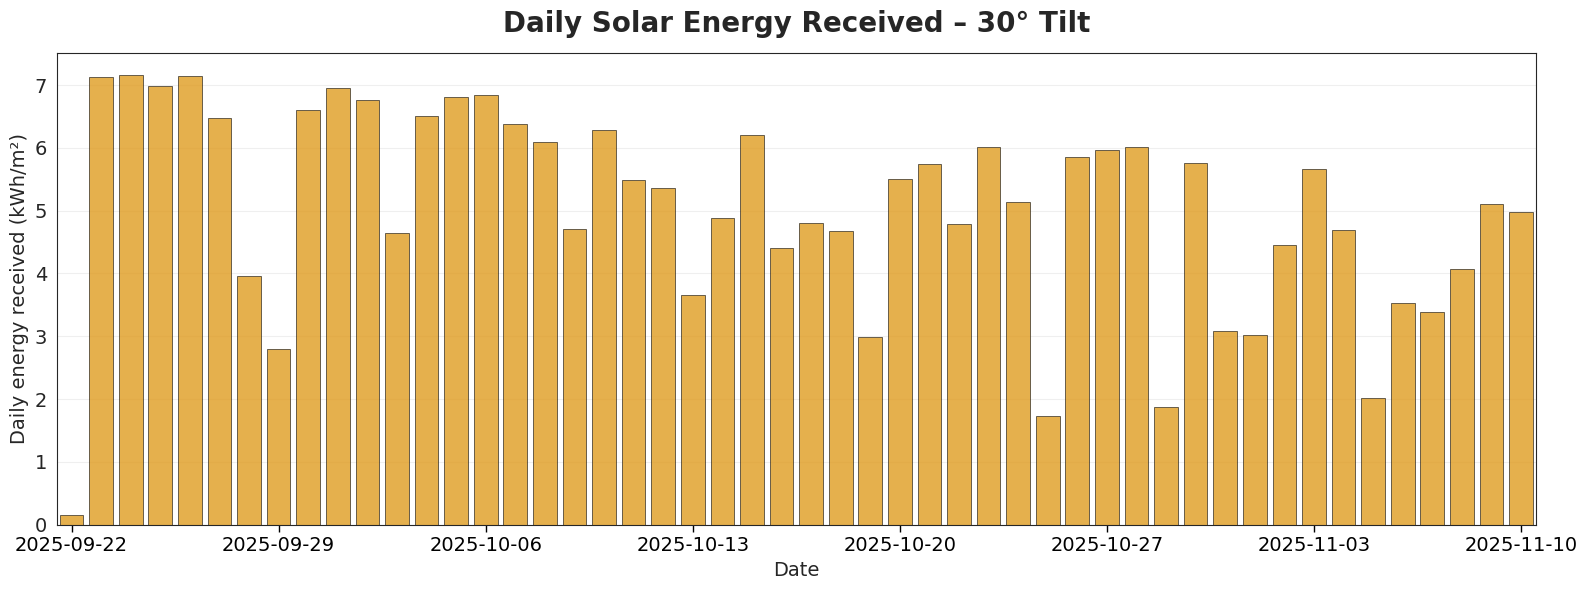

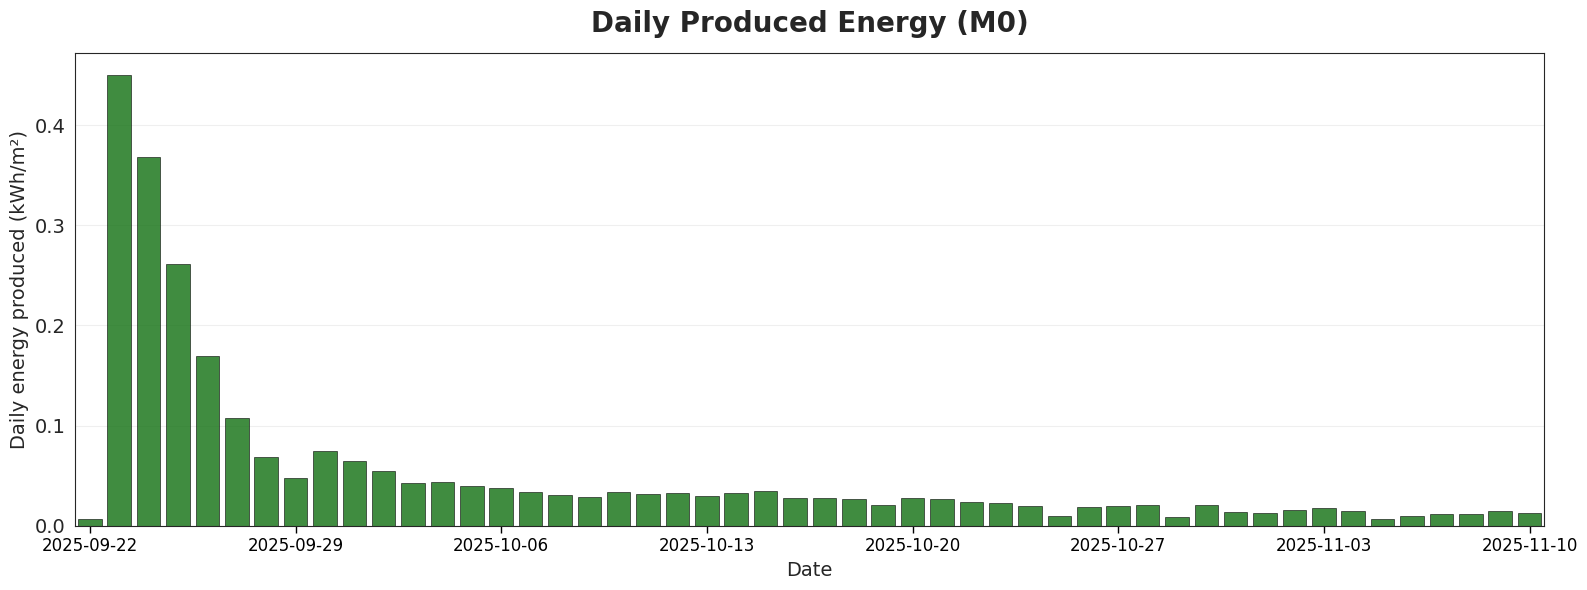

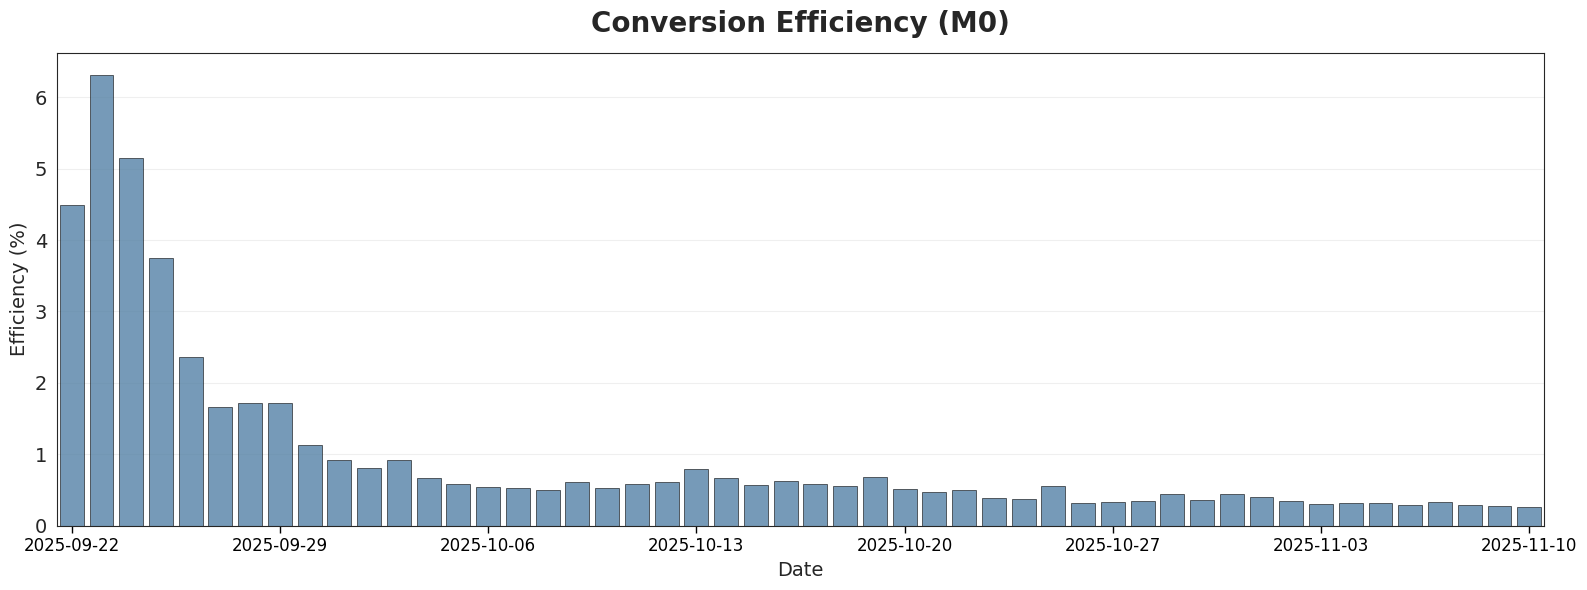

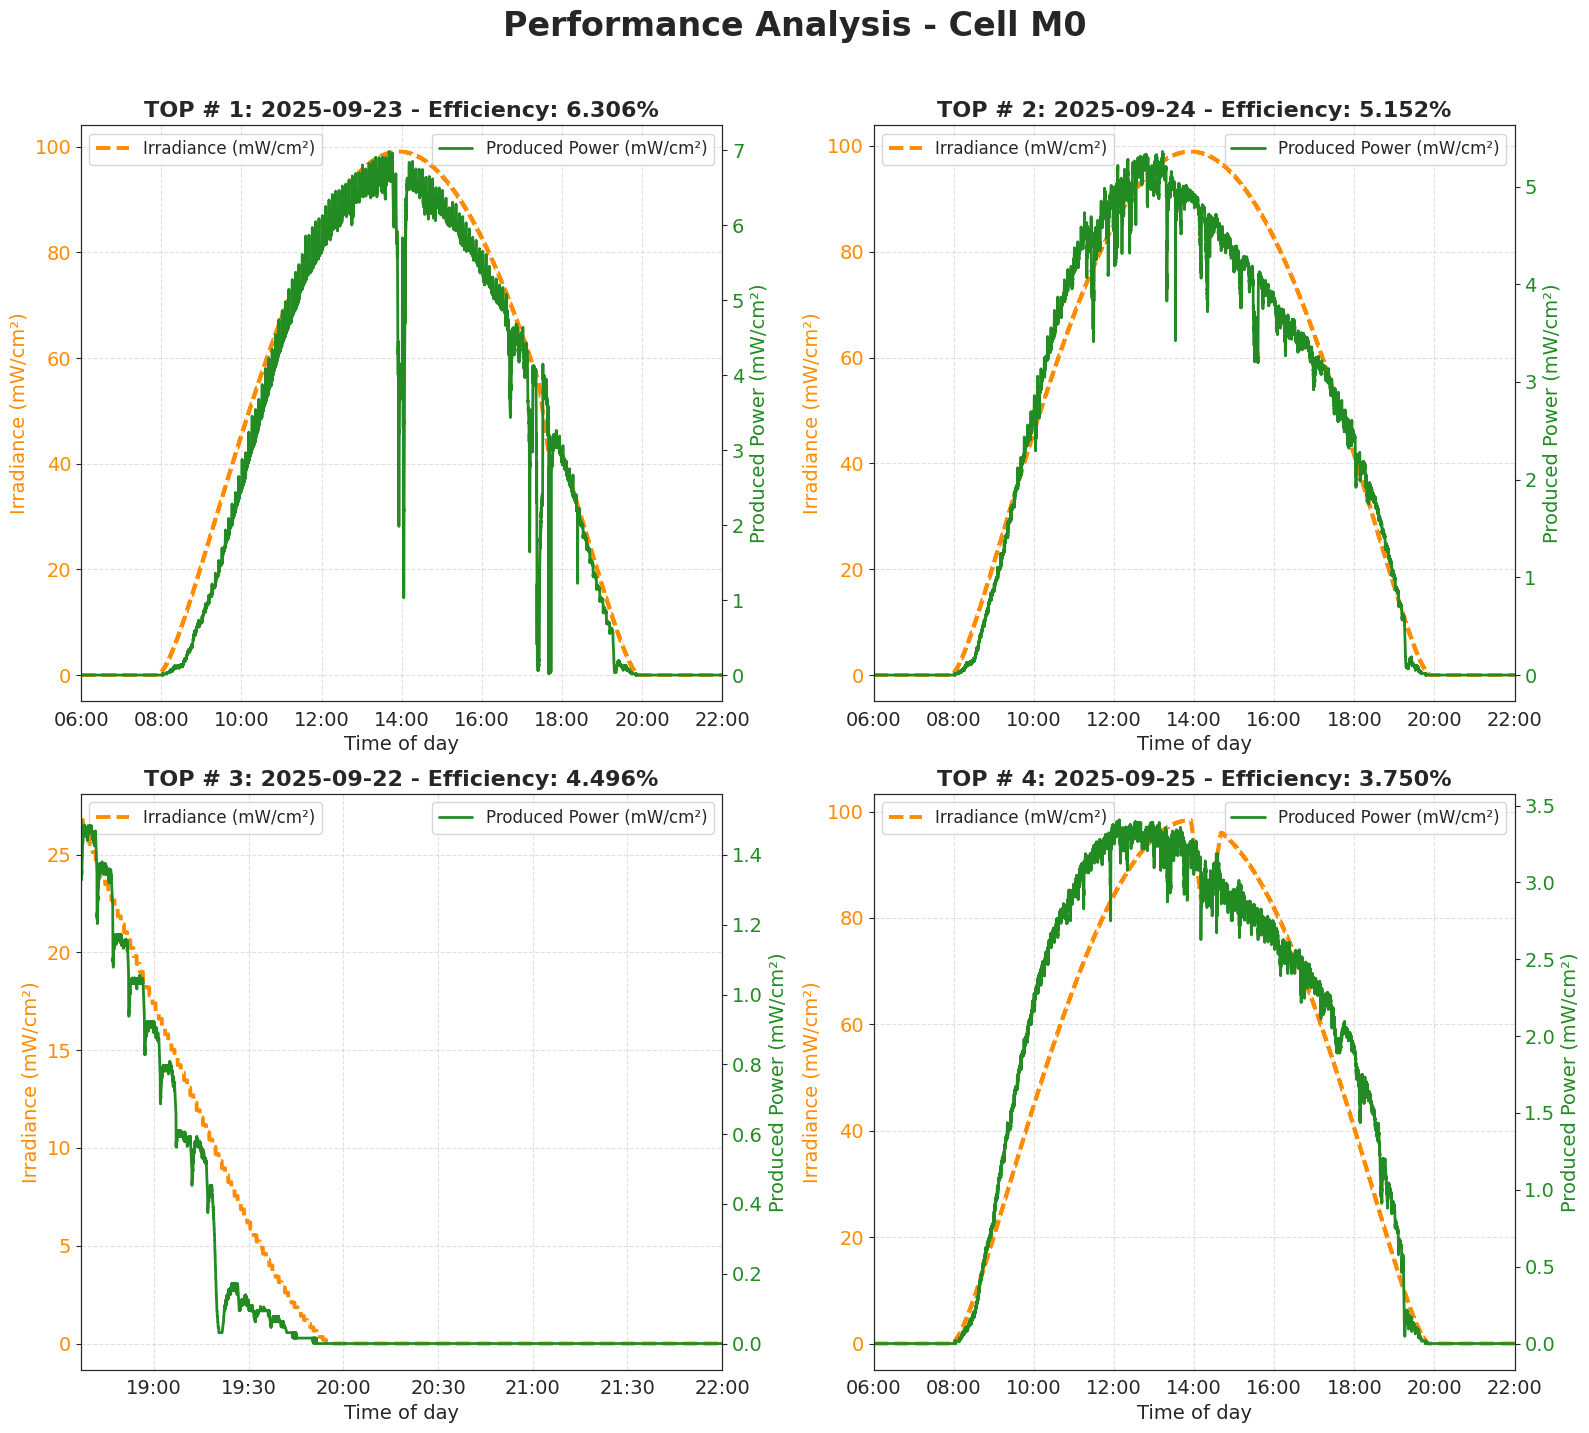

In [ ]:
analyze_mpp_efficiency('M0', clean=True)

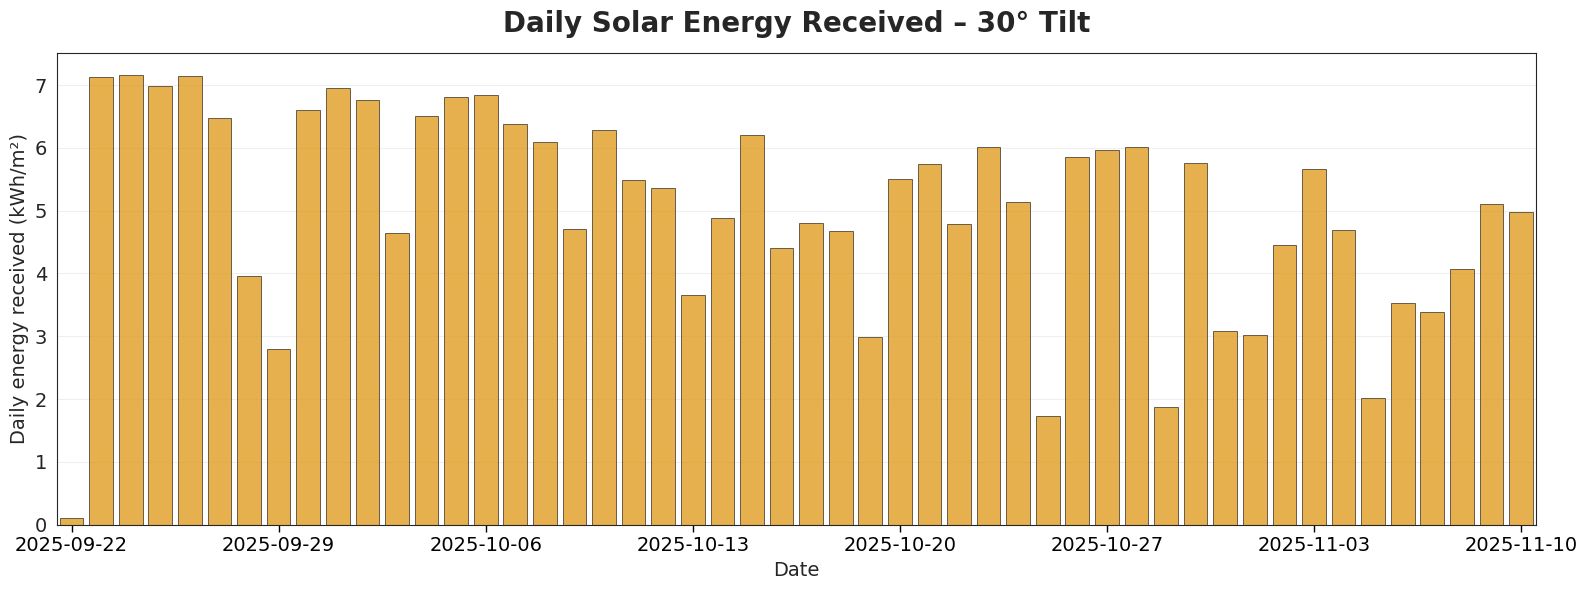

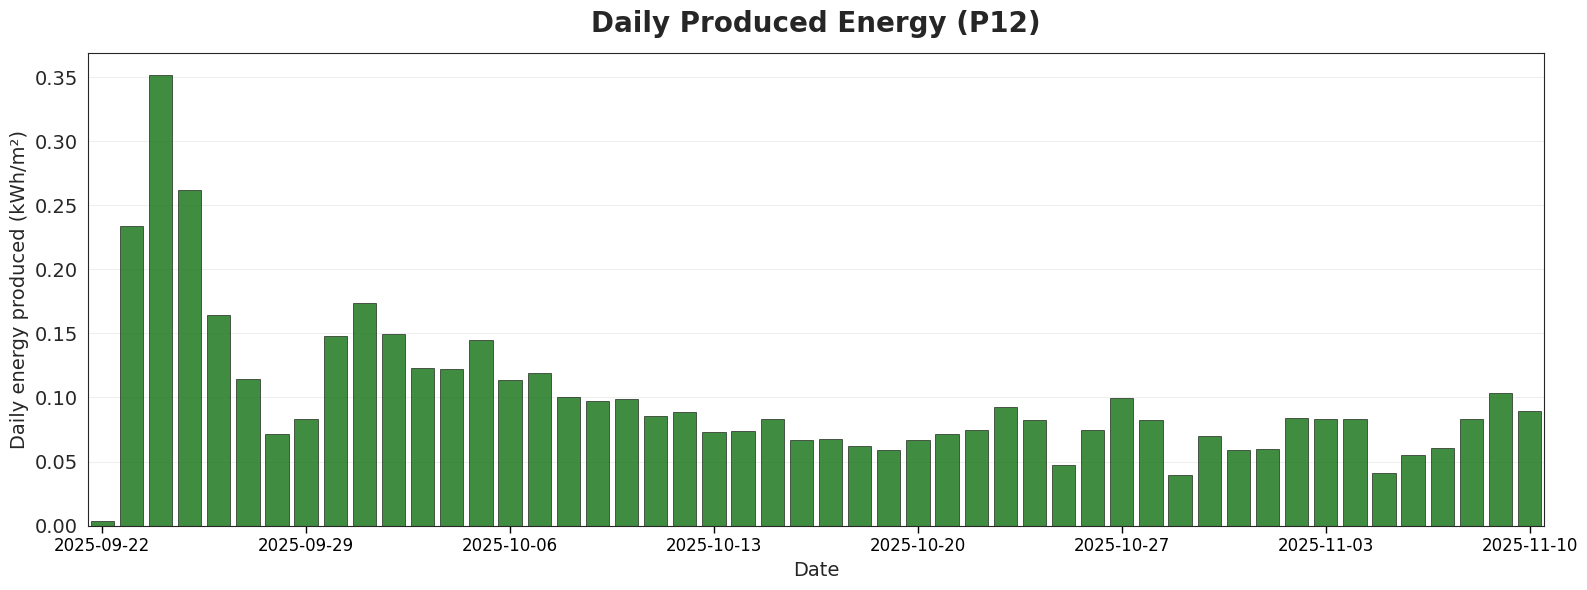

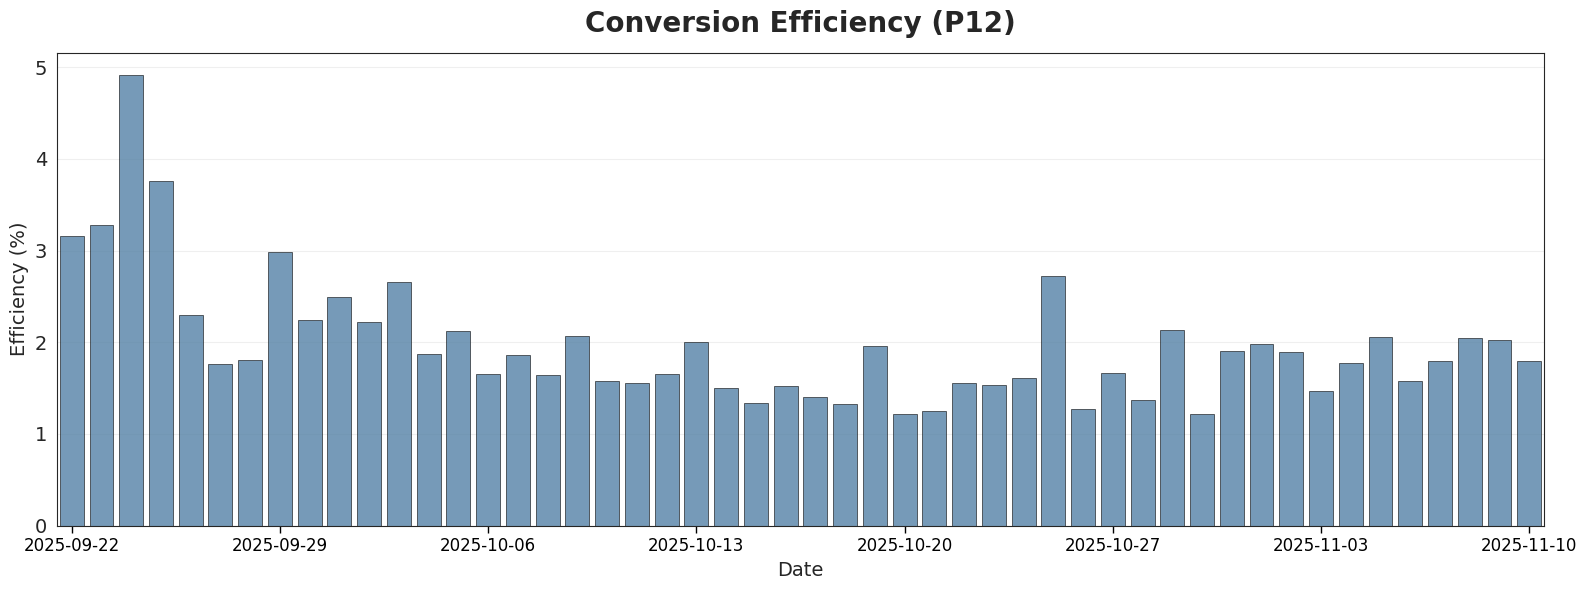

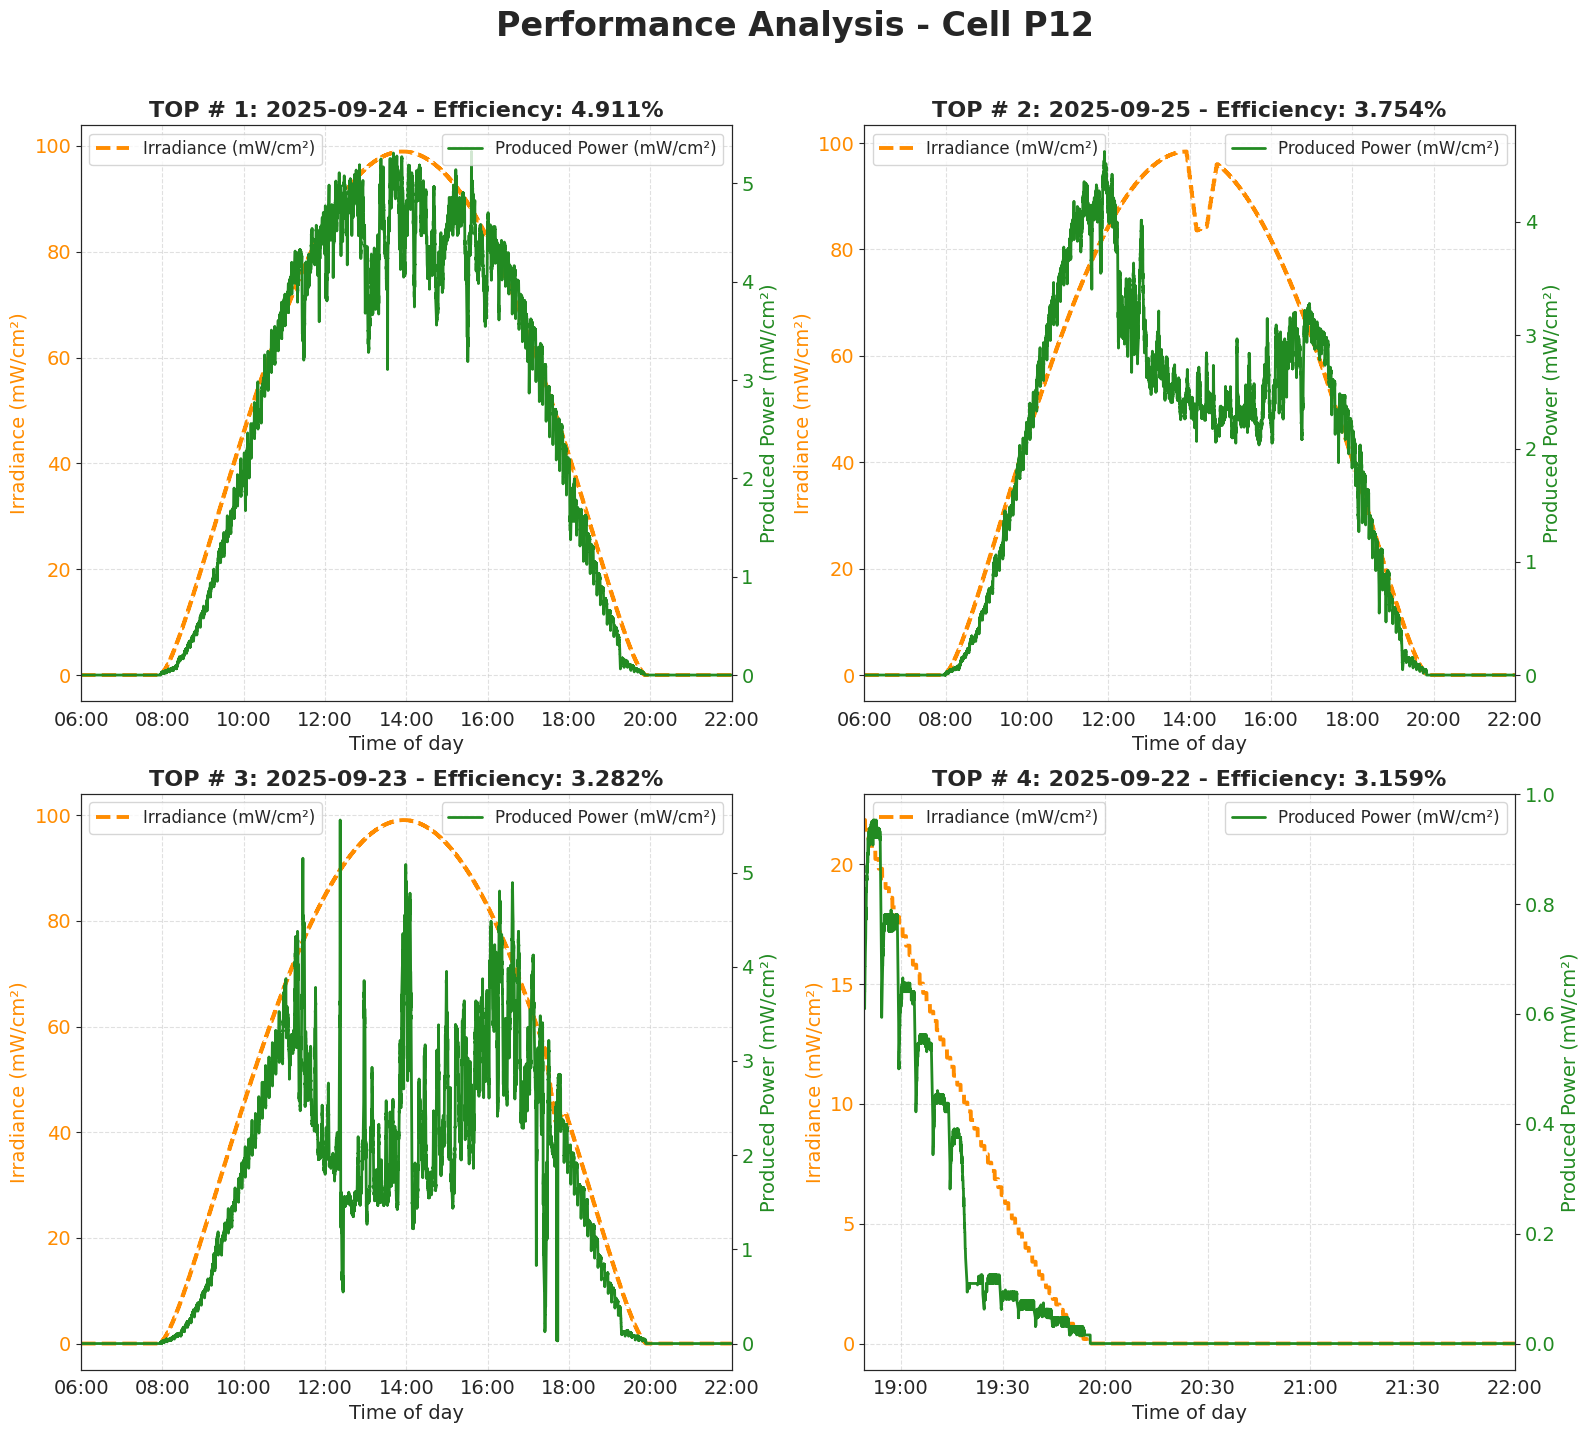

In [ ]:
analyze_mpp_efficiency('P12', clean=True)

In [ ]:
def analyze_clean_mpp_efficiency(cell_id):
    # --- Data Loading ---
    df_clean = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/TFG/Datasets/MPP/df_clean.parquet')
    if cell_id not in [0, 1]:
      print('[ERROR] cell not found')
      return
    df_clean = df_clean[df_clean['cell_id']== cell_id].copy()

    # Preprocessing
    df_clean['time'] = pd.to_datetime(df_clean['time'])
    df_clean.set_index('time', inplace=True)

    cell_id = 'M0' if cell_id==0 else 'P12'

    # --- 1. Daily Energy Received (kWh/m²) ---
    # Irradiance (mW/cm²). Sampling: 1 s.
    # Sum mW/cm² * 1 s / (3600 s/h * 10^6 mW/kW * 10^-4 m²/cm²) -> kWh/m²
    daily_received = df_clean['irradiance_30_degrees_mwcm2'].resample('D').sum() / (3600 * 100)

    plt.figure(figsize=(16, 6))
    # Using dt.strftime to make the X-axis legible in the barplot
    ax = sns.barplot(x=daily_received.index.strftime('%Y-%m-%d'),
                y=daily_received.values,
                color='orange',
                alpha=0.8,
                edgecolor='black',
                linewidth=0.5)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Daily energy received (kWh/m²)', fontsize=14)
    plt.title(f'Daily Solar Energy Received – 30° Tilt', fontsize=20, fontweight='bold', pad=15)

    # Define the step (every 7 days)
    step = 7
    plt.xticks(ticks=range(0, len(daily_received), step), labels=daily_received.index[::step].strftime('%Y-%m-%d'), ha='center', fontsize=14)

    # Add ticks
    ax.tick_params(axis='x', which='major', bottom=True, length=5, width=1, colors='black')

    plt.yticks(fontsize=14)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- 2. Energy Produced (kWh) ---
    # Power (mW/cm²). Sampling: 1 s.
    # Sum mW/cm² * 1 s / (3600 s/h * 10^6 mW/kW * 10^-4 m²/cm²) -> kWh/m²

    daily_produced = df_clean['power_cell_mwcm2'].resample('D').sum() / (3600 * 100)

    # Plot Produced
    plt.figure(figsize=(16, 6))
    ax = sns.barplot(x=daily_produced.index.strftime('%Y-%m-%d'),
                y=daily_produced.values,
                color='green',
                alpha=0.8,
                edgecolor='black',
                linewidth=0.5)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Daily energy produced (kWh/m²)', fontsize=14)
    plt.title(f'Daily Produced Energy ({cell_id})', fontsize=20, fontweight='bold', pad=15)

    # Define the step (every 7 days)
    step = 7
    plt.xticks(ticks=range(0, len(daily_produced), step), labels=daily_produced.index[::step].strftime('%Y-%m-%d'), ha='center', fontsize=12)

    # Add ticks
    ax.tick_params(axis='x', which='major', bottom=True, length=5, width=1, colors='black')

    plt.yticks(fontsize=14)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- 4. Efficiency (%) ---
    # Formula: (Produced / Received) * 100

    # Align indices to ensure we divide the same days. (Pandas does this automatically, but this prevents errors if days are missing in one)
    aligned_produced, aligned_received = daily_produced.align(daily_received, join='inner')

    eff = (aligned_produced / aligned_received) * 100

    # Cleaning: Drop NaNs and Infinite values
    eff = eff.replace([np.inf, -np.inf], np.nan).dropna()

    # Plot Efficiency
    plt.figure(figsize=(16, 6))
    ax = sns.barplot(x=eff.index.strftime('%Y-%m-%d'),
                y=eff.values,
                color='steelblue',
                alpha=0.8,
                edgecolor='black',
                linewidth=0.5)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Efficiency (%)', fontsize=14)
    plt.title(f'Conversion Efficiency ({cell_id})', fontsize=20, fontweight='bold', pad=15)

    # Define the step (every 7 days)
    step = 7
    plt.xticks(ticks=range(0, len(eff), step), labels=eff.index[::step].strftime('%Y-%m-%d'), ha='center', fontsize=12)

    # Add ticks
    ax.tick_params(axis='x', which='major', bottom=True, length=5, width=1, colors='black')

    plt.yticks(fontsize=14)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- 5. Top 4 Curves ---

    # Sort efficiency to get the best days
    eff_best = eff.sort_values(ascending=False)

    # --- 2. Visualization ---
    fig, axs = plt.subplots(2, 2, figsize=(16, 14))
    fig.suptitle(f'Performance Analysis - Cell {cell_id}', fontsize=24, fontweight='bold', y=1.02)

    indices_to_plot = [0, 1, 2, 3]

    for k, ax in zip(indices_to_plot, axs.ravel()):
        # Get the date for the k-th best efficiency day
        target_date = eff_best.index[k].date()

        # Filter CAMS for the day and time range (06:00 - 22:00)
        day_cams = df_clean[df_clean.index.date == target_date]
        day_cams = day_cams.between_time('06:00', '22:00').copy()

        # Filter PP for the day and time range
        day_pp = df_clean[df_clean.index.date == target_date]
        day_pp = day_pp.between_time('06:00', '22:00').copy()

        # Re-format index to generic datetime for consistent plotting on the X-axis
        # (This avoids issues with specific dates and focuses on time)
        day_cams.index = pd.to_datetime(day_cams.index.strftime('%H:%M:%S'), format='%H:%M:%S')
        day_pp.index = pd.to_datetime(day_pp.index.strftime('%H:%M:%S'), format='%H:%M:%S')

        # --- Plotting ---
        sns.set_style("white")

        # Axis 1: Irradiance
        ax1 = ax
        sns.lineplot(
            x=day_cams.index,
            y=day_cams['irradiance_30_degrees_mwcm2'],
            linewidth=2.8,
            linestyle='--',
            color='darkorange',
            label='Irradiance (mW/cm²)',
            ax=ax1,
            errorbar=None
        )

        ax1.set_xlabel('Time of day', fontsize=14)
        ax1.set_ylabel('Irradiance (mW/cm²)', color='darkorange', fontsize=14)
        ax1.tick_params(axis='y', labelcolor='darkorange', labelsize=14)

        # Axis 2: Power Produced (Twin axis)
        ax2 = ax1.twinx()
        sns.lineplot(
            x=day_pp.index,
            y=day_pp['power_cell_mwcm2'],
            color='forestgreen',
            linewidth=2,
            label='Produced Power (mW/cm²)',
            ax=ax2
        )

        ax2.set_ylabel('Produced Power (mW/cm²)', color='forestgreen', fontsize=14)
        ax2.tick_params(axis='y', labelcolor='forestgreen', labelsize=14)

        # Title and Formatting
        ax1.set_title(f'TOP # {k+1}: {target_date} - Efficiency: {eff_best.iloc[k]:.3f}%',
                      fontsize=16, fontweight='bold')

        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax1.tick_params(axis='x', labelsize=14)

        # Sync X-axis limits
        if not day_pp.empty:
            ax1.set_xlim([day_pp.index[0], day_pp.index[-1]])

        ax1.grid(True, linestyle='--', alpha=0.6)

        # Legends
        ax1.legend(loc='upper left', fontsize=12)
        ax2.legend(loc='upper right', fontsize=12)

    plt.tight_layout()
    plt.show()

    return

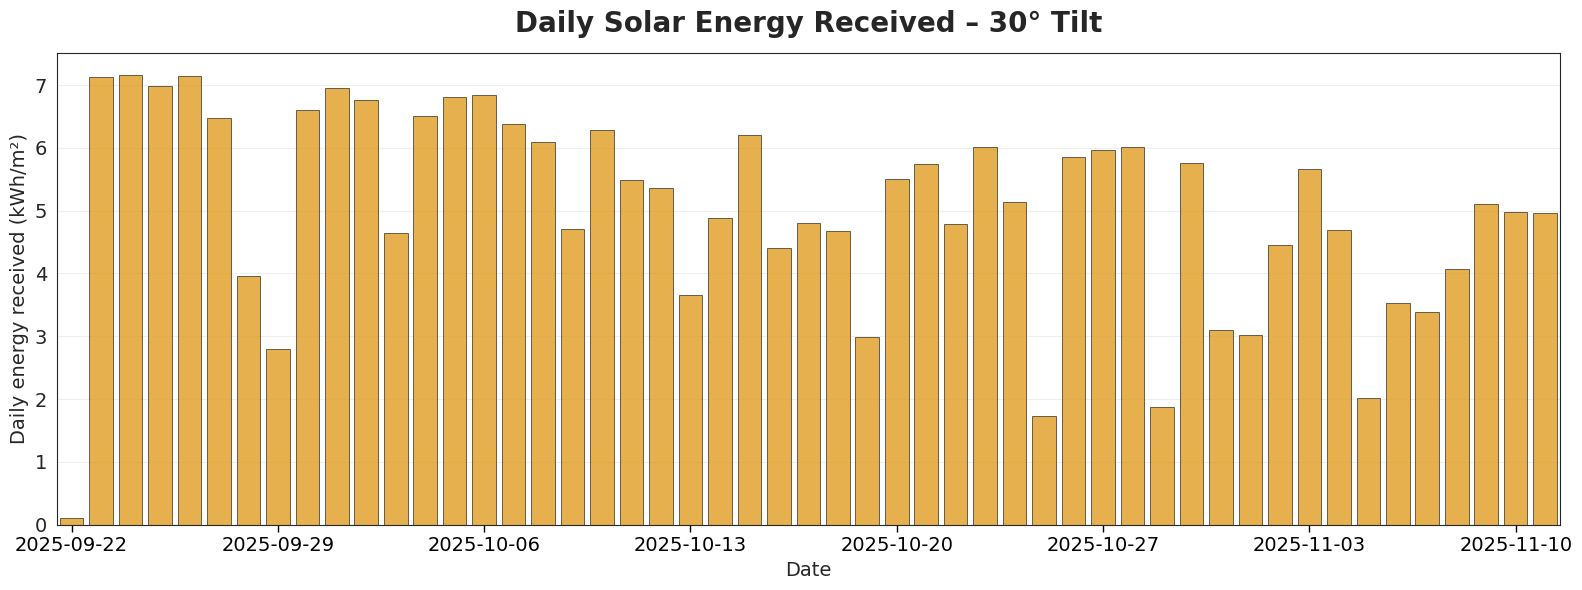

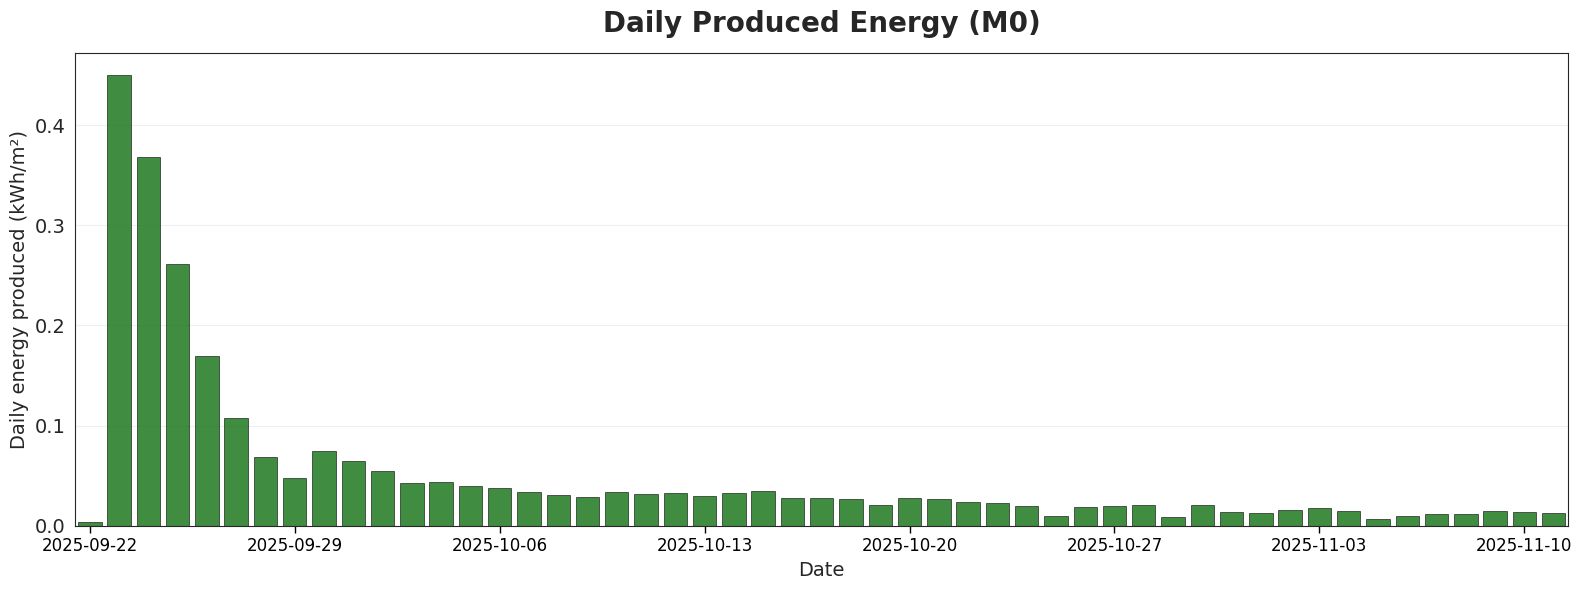

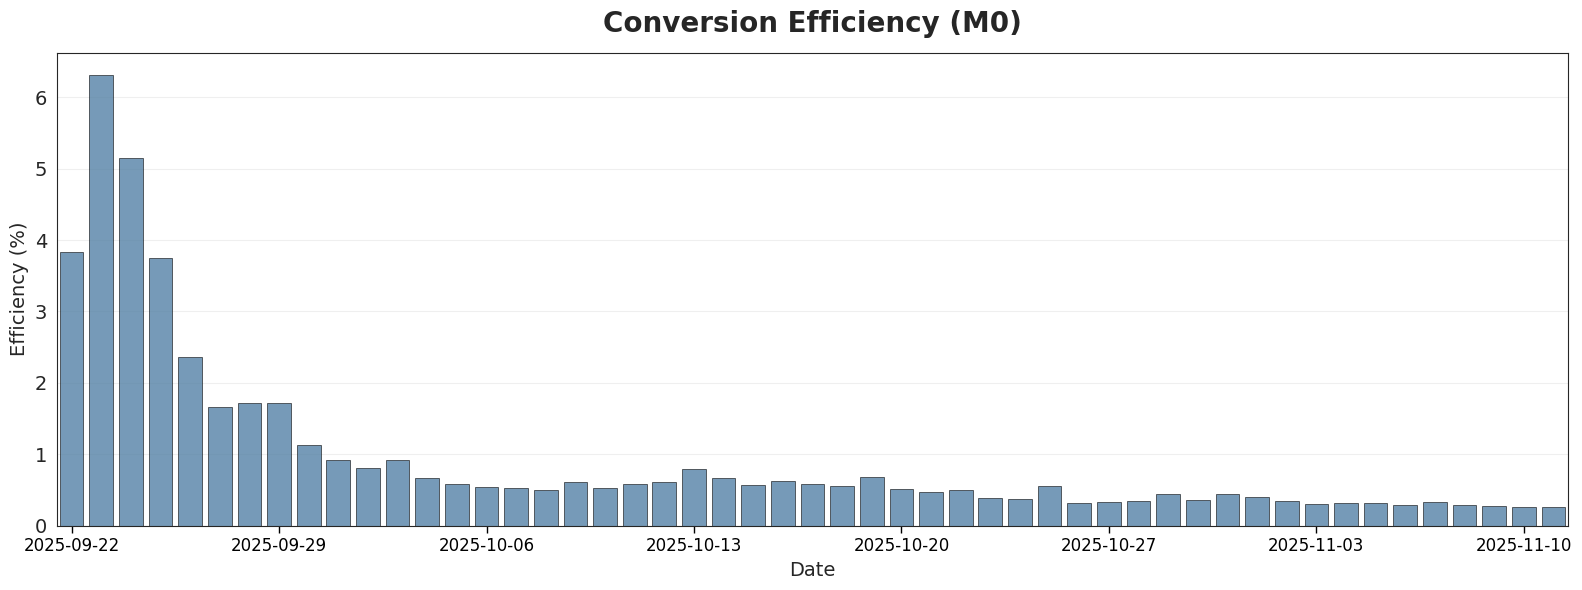

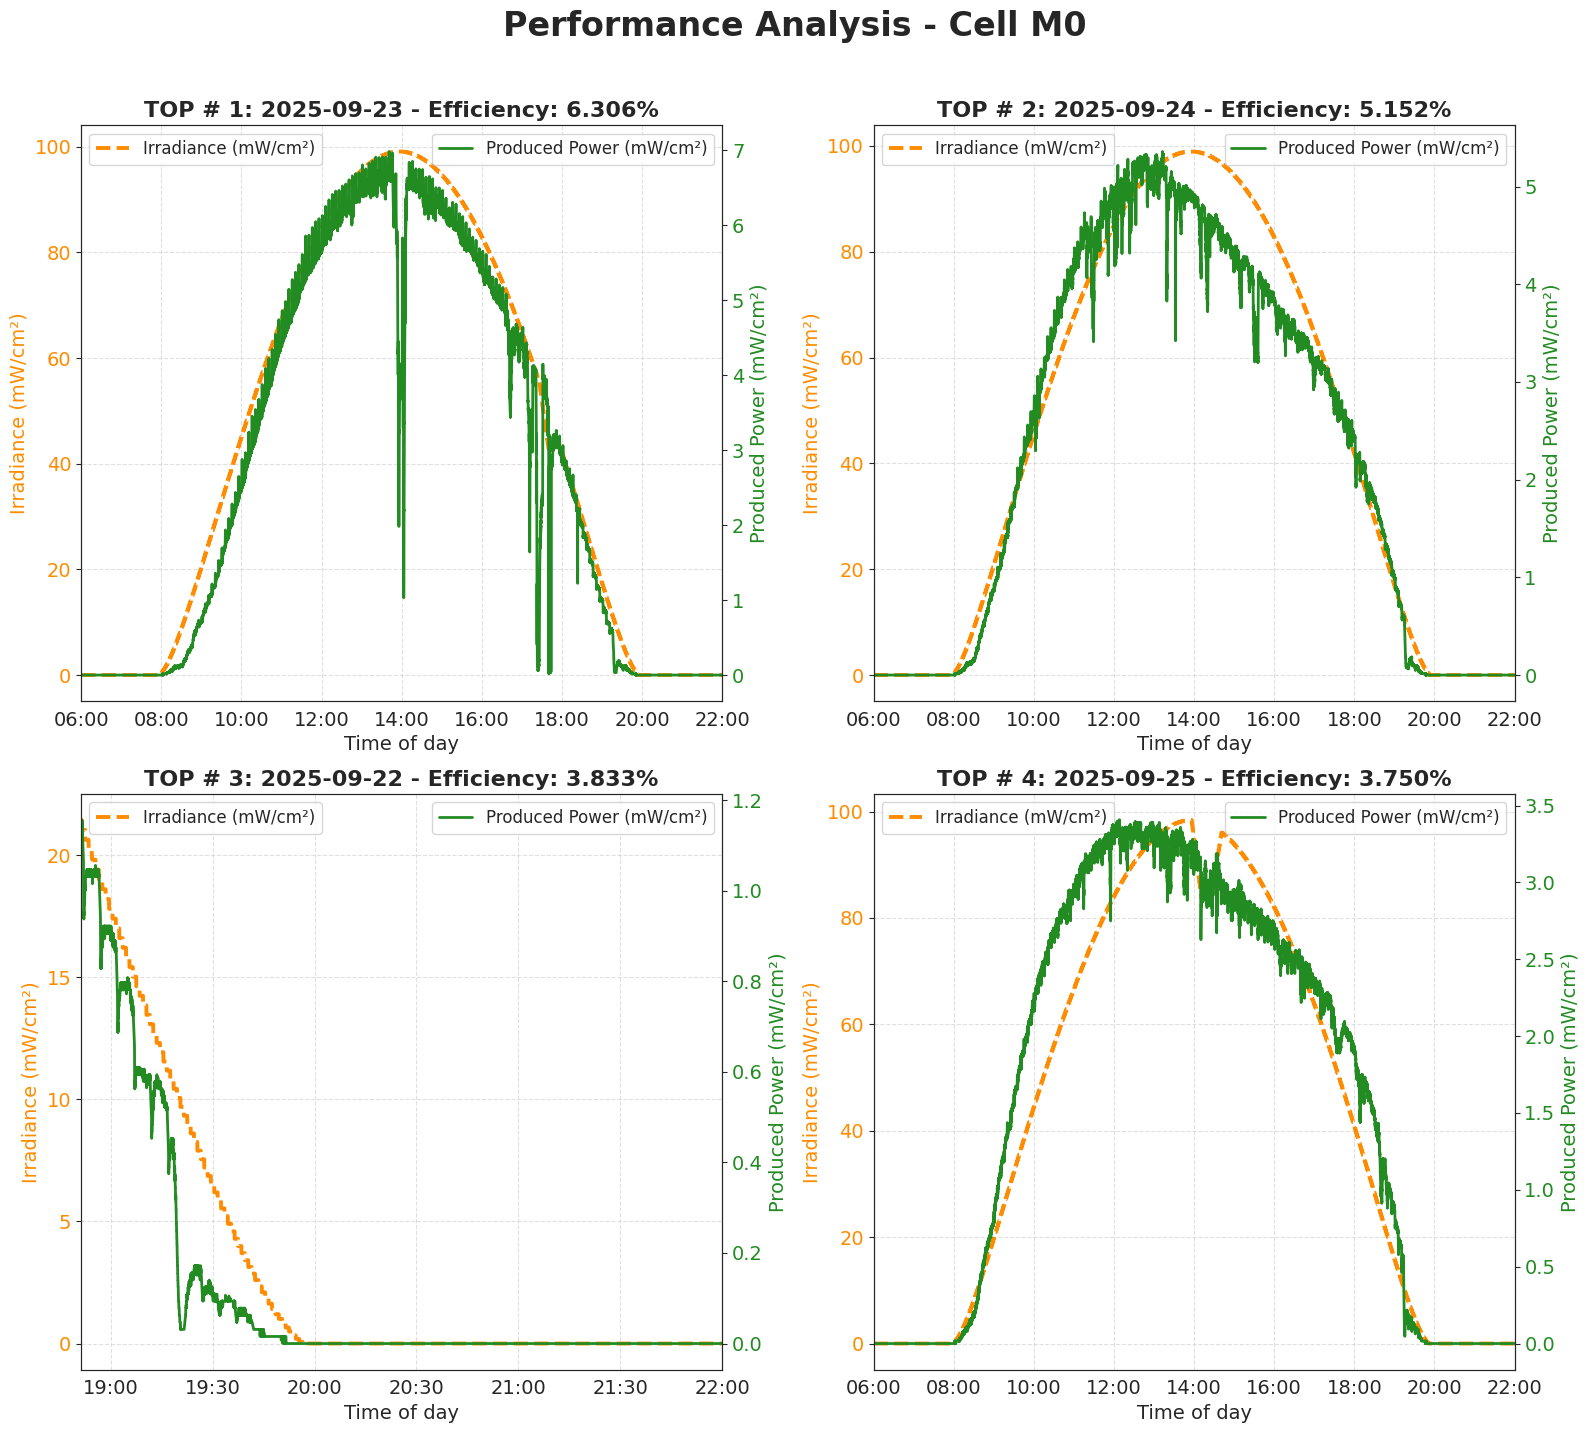

In [ ]:
analyze_clean_mpp_efficiency(cell_id=0)

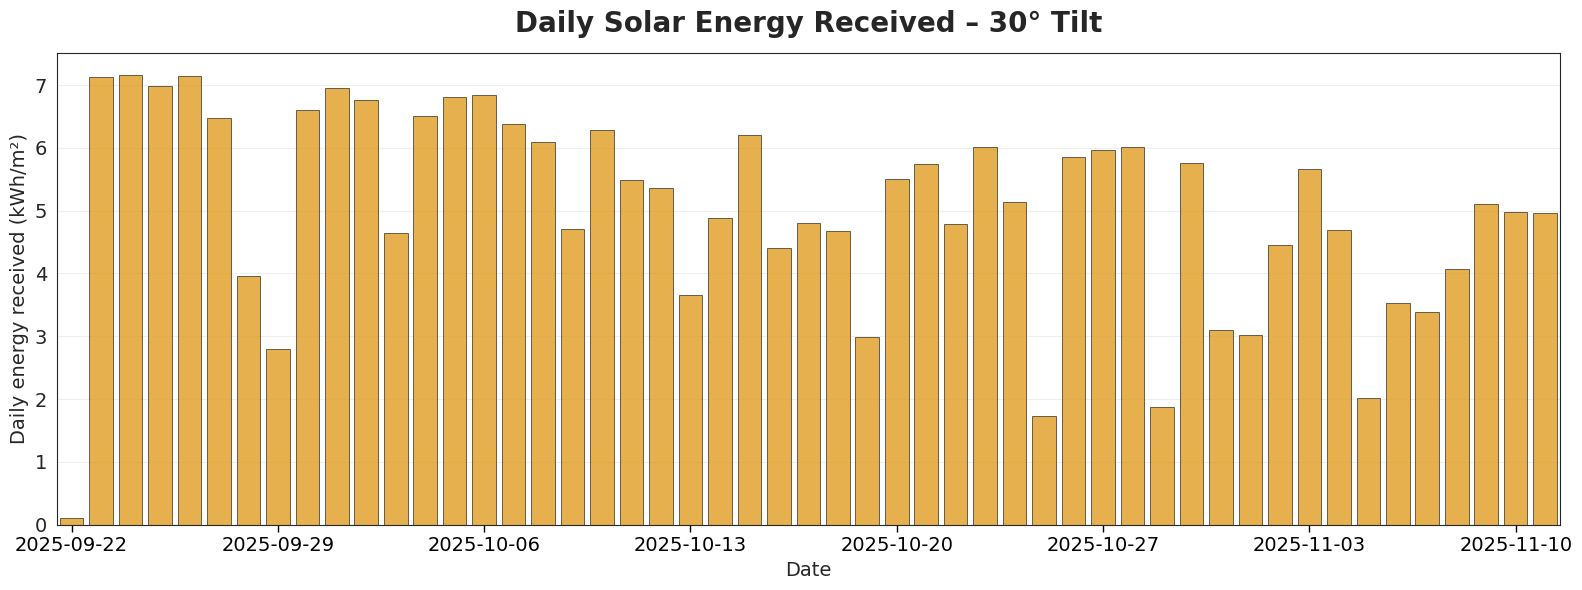

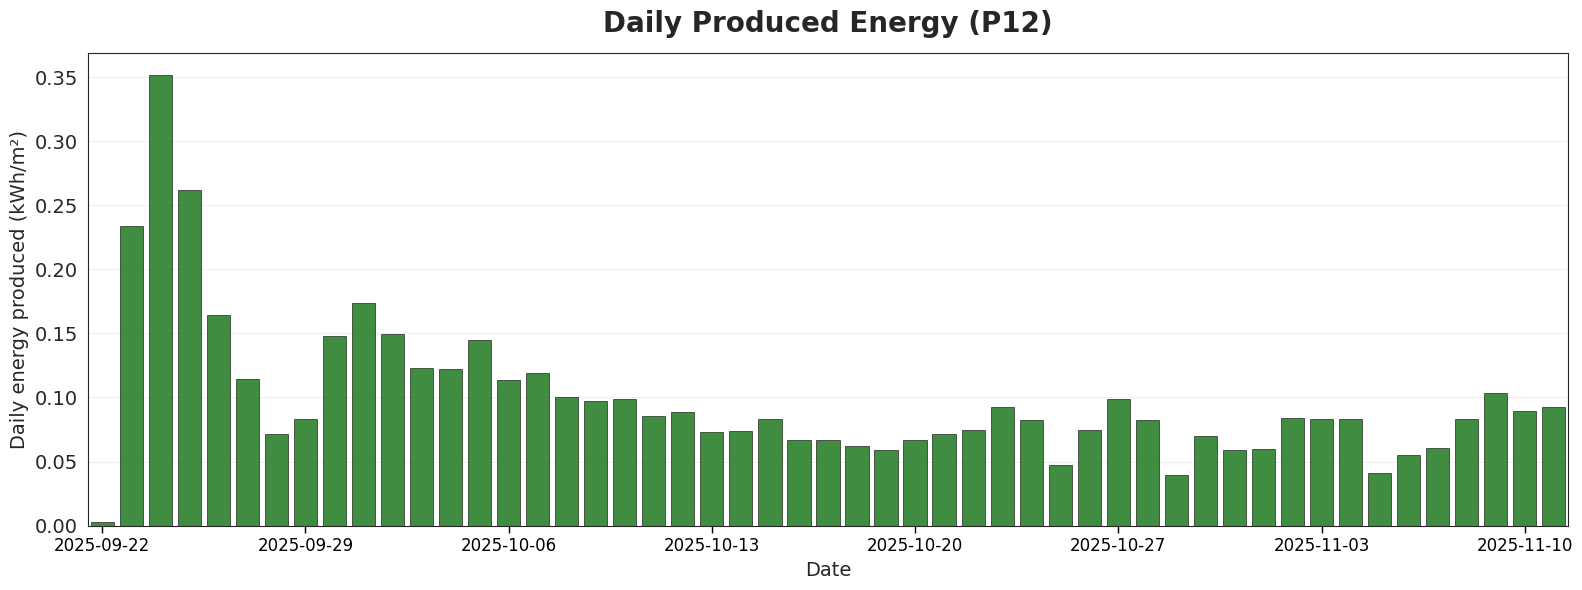

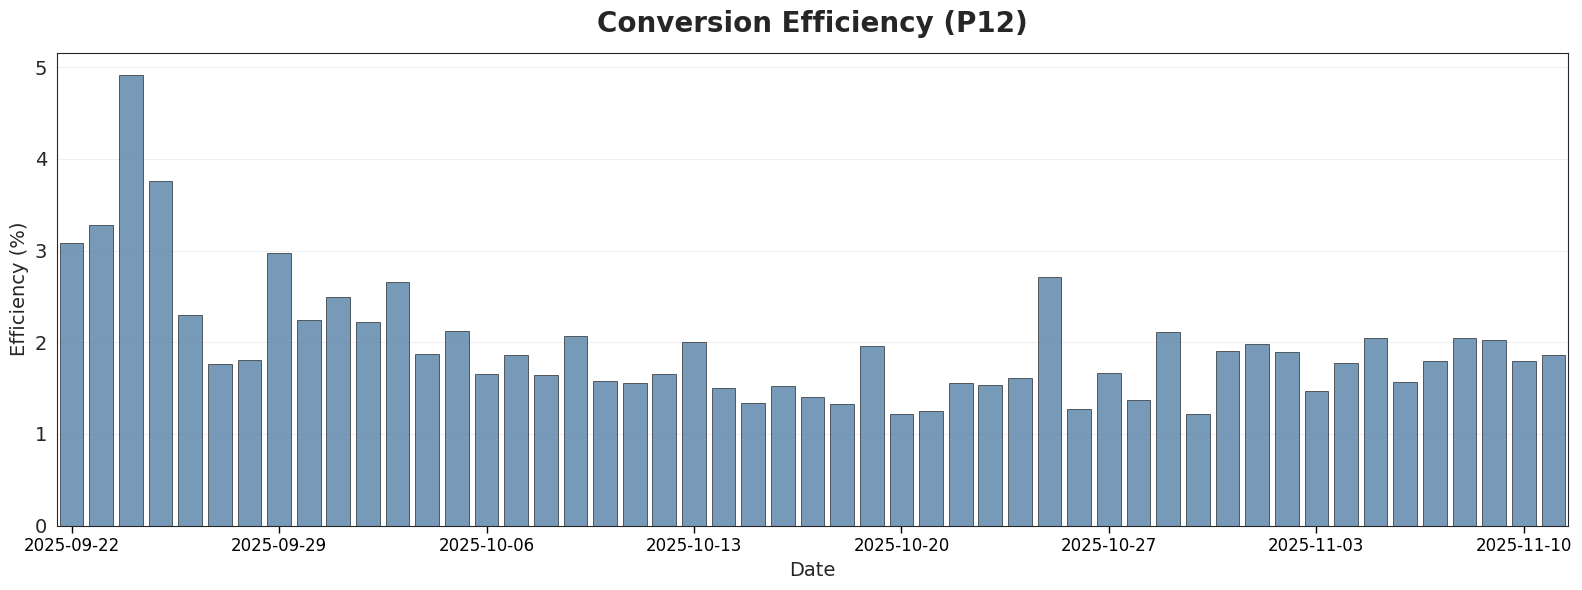

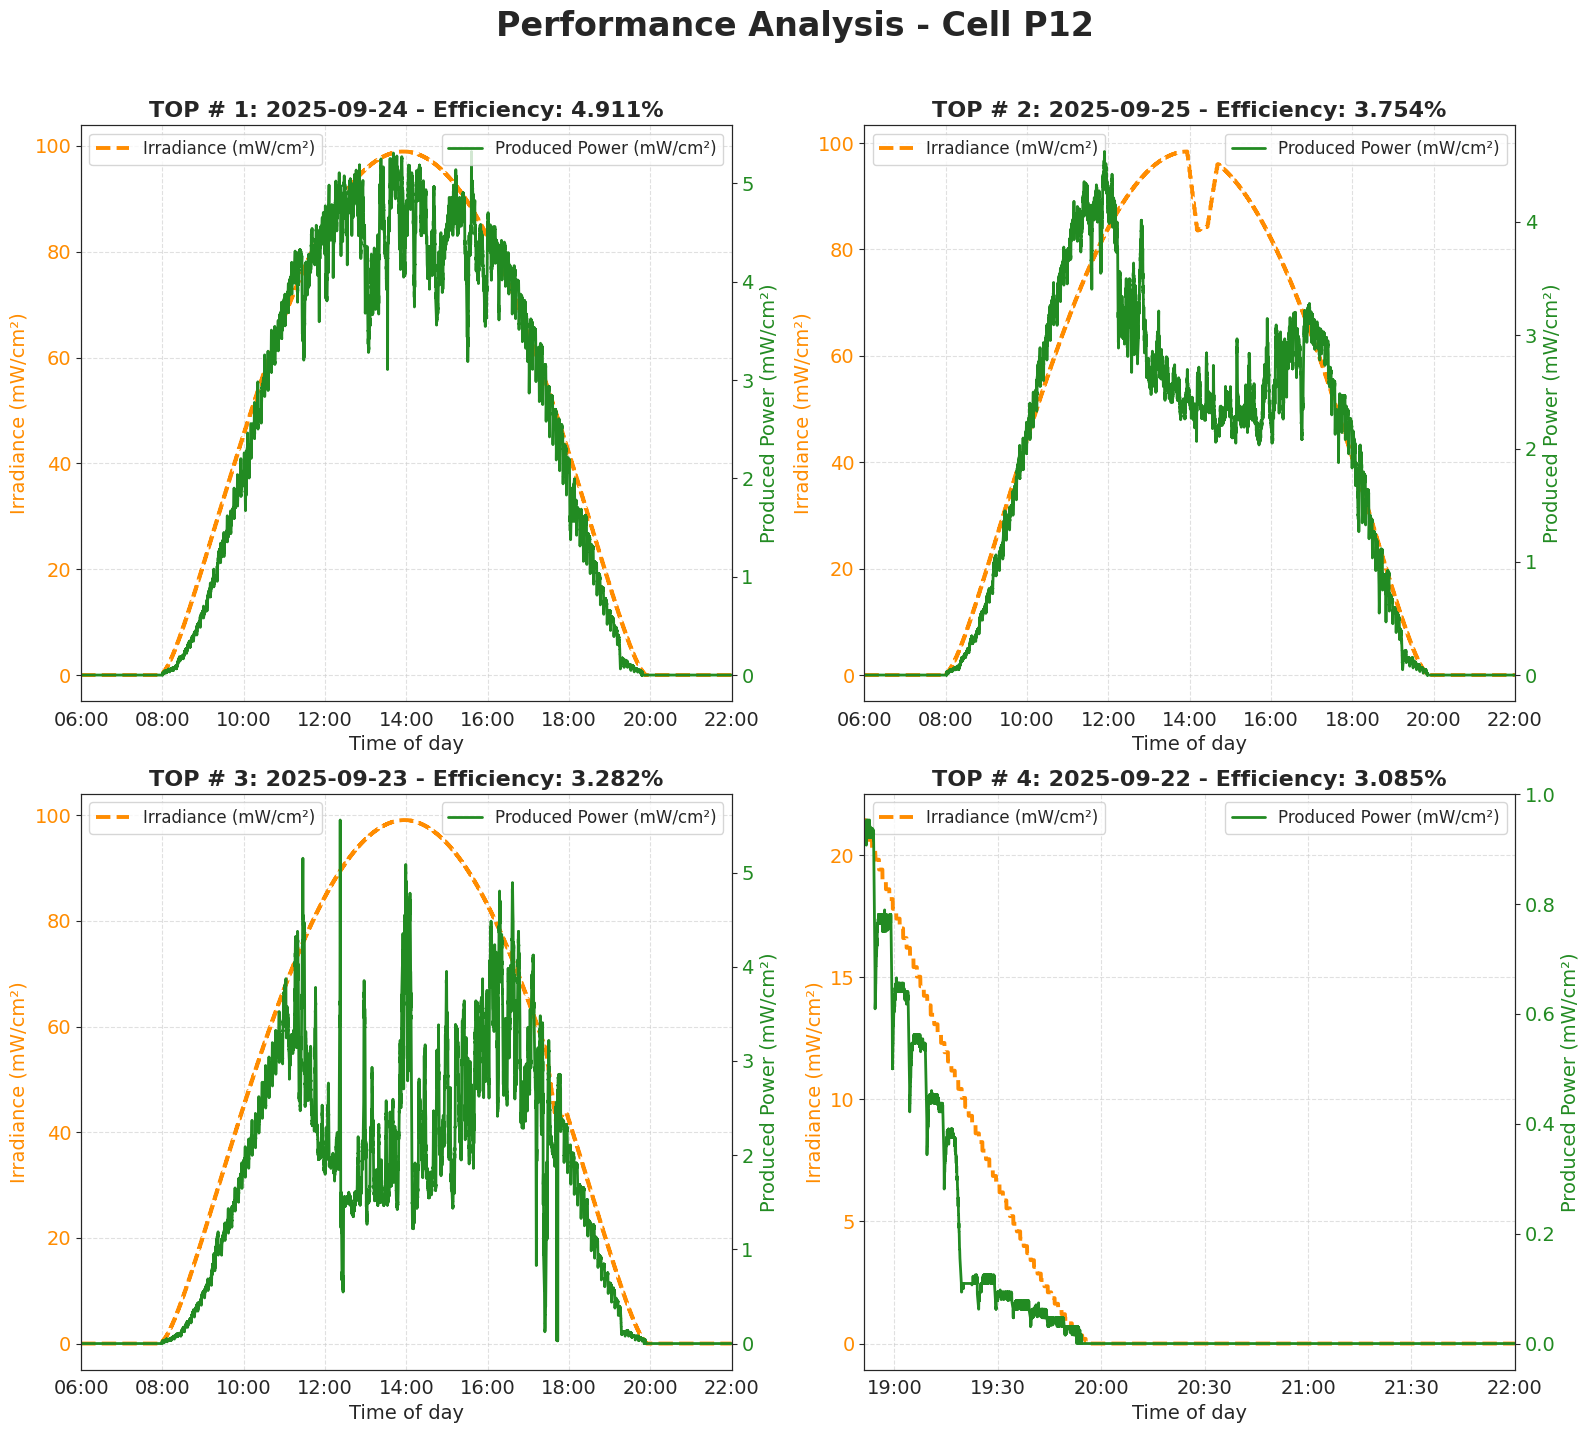

In [ ]:
analyze_clean_mpp_efficiency(cell_id=1)

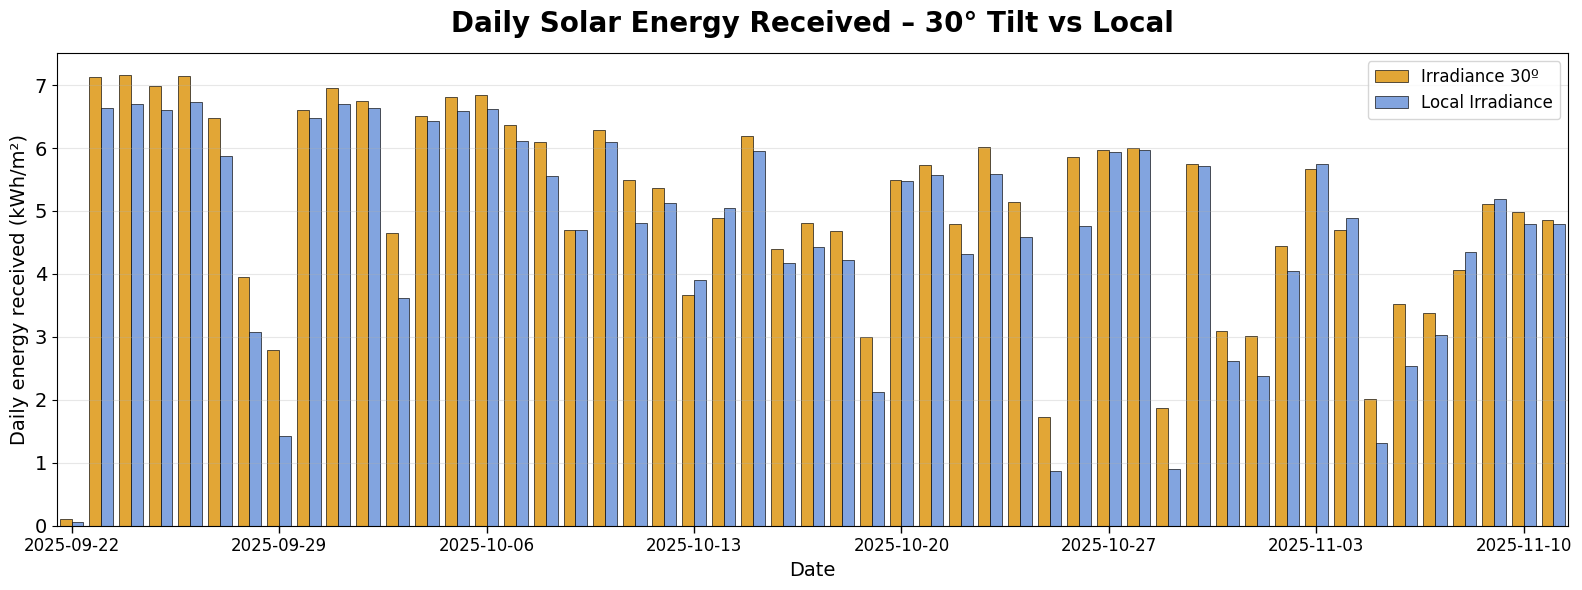

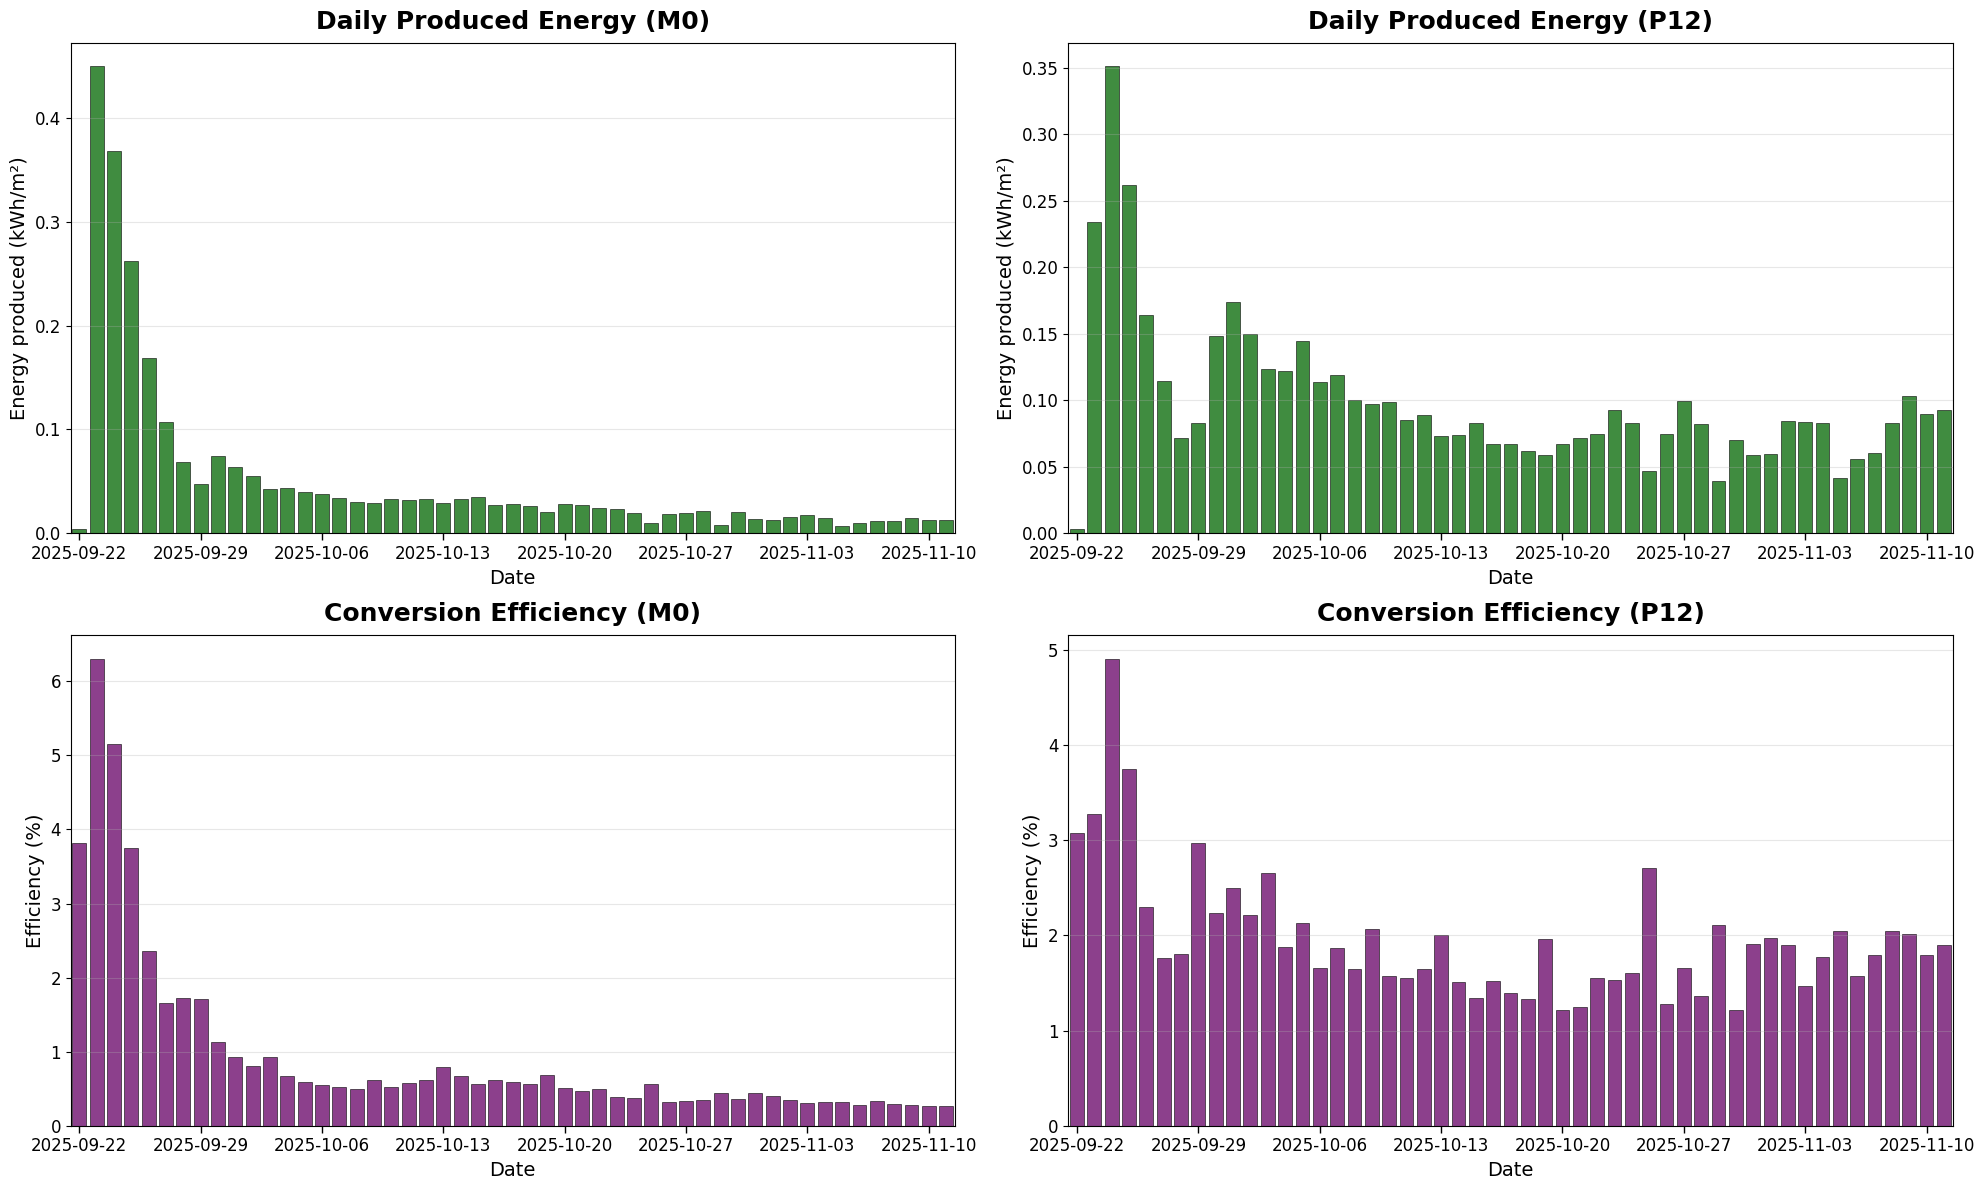

In [ ]:
df = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/TFG/Datasets/MPP/df_clean.parquet')
df = df.drop(columns=['power_art', 'local_irradiance_art', 'smooth_local_irradiance_mwcm2', 'hour_fraction', 'hour_sin',
       'hour_cos', 'cams_irradiance_art','DeviceTemp', 't_chamber',
       'AmbientTemp', 'Humidity', 'index', 'id_curve', 'label_curve', 'ff_fwd',
       'ff_rev', 'jsc_fwd', 'jsc_rev', 'p_mpp_fwd', 'p_mpp_rev', 'time_fwd',
       'time_rev', 'v_mpp_fwd', 'v_mpp_rev', 'voc_fwd', 'voc_rev', 'time_avg',
       'is_ffill'])

def analyze_mpp_efficiency(df):
    # --- 0. Basic Preprocessing ---
    # Ensure we don't alter the original df and that 'time' is the datetime index
    df = df.copy()
    if 'time' in df.columns:
        df['time'] = pd.to_datetime(df['time'])
        df.set_index('time', inplace=True)
    else:
        df.index = pd.to_datetime(df.index)

    # Conversion factor (mW/cm² to kWh/m² with data sampled every 1 second):
    # Sum W/m² * 1 s / (3600 s/h * 10^6 mW/kW * 10^-4 m²/cm²) -> Sum / 360000
    conversion_factor = 3600 * 100

    # Dictionary to map cell IDs to their corresponding names
    cell_names = {0: "M0", 1: "P12"}

    # =========================================================================
    # 1. Daily Energy Received (kWh/m²) - Single Plot
    # =========================================================================
    # Filter for just one cell to avoid summing duplicate irradiance timestamps
    df_irradiance = df[df['cell_id'] == 0]

    daily_received_30 = df_irradiance['irradiance_30_degrees_mwcm2'].resample('D').sum() / conversion_factor
    daily_received_local = df_irradiance['local_irradiance_mwcm2'].resample('D').sum() / conversion_factor

    # Filter valid days
    valid_days = daily_received_30 >= 0
    daily_received_30 = daily_received_30[valid_days]
    daily_received_local = daily_received_local[valid_days]

    df_plot = pd.DataFrame({
        'Date': daily_received_30.index.strftime('%Y-%m-%d'),
        'Irradiance 30º': daily_received_30.values,
        'Local Irradiance': daily_received_local.values
    })

    df_melted = df_plot.melt(id_vars='Date', var_name='Type', value_name='Energy')

    plt.figure(figsize=(16, 6))

    ax = sns.barplot(data=df_melted,
                     x='Date',
                     y='Energy',
                     hue='Type',
                     palette={'Irradiance 30º': 'orange', 'Local Irradiance': '#6495ED'},
                     edgecolor='black',
                     linewidth=0.5,
                     alpha=0.9)

    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Daily energy received (kWh/m²)', fontsize=14)
    plt.title('Daily Solar Energy Received – 30° Tilt vs Local', fontsize=20, fontweight='bold', pad=15)

    # Configure ticks (every 7 days)
    unique_dates = df_plot['Date'].unique()
    step = 7
    plt.xticks(ticks=range(0, len(unique_dates), step),
               labels=unique_dates[::step],
               ha='center', fontsize=12)

    ax.tick_params(axis='x', which='major', bottom=True, length=5, width=1, colors='black')
    plt.yticks(fontsize=14)
    plt.legend(fontsize=12, title=None)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


    # =========================================================================
    # 2. 2x2 Subplots: Produced Energy & Efficiency (Left: M0, Right: P12)
    # =========================================================================
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 12))

    # Loop through the columns (0 for M0, 1 for P12)
    for col_idx, cell_id in enumerate([0, 1]):
        df_cell = df[df['cell_id'] == cell_id]
        cell_label = cell_names.get(cell_id, f"Cell {cell_id}")

        # --- Calculate Energy Produced ---
        daily_produced = df_cell['power_cell_mwcm2'].resample('D').sum() / conversion_factor
        daily_produced = daily_produced[daily_produced >= 0]

        # --- Calculate Efficiency ---
        # Recalculate daily received for this specific cell to align perfectly with its own produced data length
        daily_received_cell = df_cell['irradiance_30_degrees_mwcm2'].resample('D').sum() / conversion_factor
        aligned_produced, aligned_received = daily_produced.align(daily_received_cell, join='inner')

        eff = (aligned_produced / aligned_received) * 100
        eff = eff.replace([np.inf, -np.inf], np.nan).dropna()

        # --- Row 1: Plot Produced Energy ---
        sns.barplot(x=daily_produced.index.strftime('%Y-%m-%d'),
                    y=daily_produced.values,
                    color='green',
                    alpha=0.8,
                    edgecolor='black',
                    linewidth=0.5,
                    ax=axes[0, col_idx])

        axes[0, col_idx].set_title(f'Daily Produced Energy ({cell_label})', fontsize=18, fontweight='bold', pad=10)
        axes[0, col_idx].set_xlabel('Date', fontsize=14)
        axes[0, col_idx].set_ylabel('Energy produced (kWh/m²)', fontsize=14)

        # --- Row 2: Plot Efficiency ---
        sns.barplot(x=eff.index.strftime('%Y-%m-%d'),
                    y=eff.values,
                    color='purple',
                    alpha=0.8,
                    edgecolor='black',
                    linewidth=0.5,
                    ax=axes[1, col_idx])

        axes[1, col_idx].set_title(f'Conversion Efficiency ({cell_label})', fontsize=18, fontweight='bold', pad=10)
        axes[1, col_idx].set_xlabel('Date', fontsize=14)
        axes[1, col_idx].set_ylabel('Efficiency (%)', fontsize=14)

        # --- Format ticks for both subplots in the column ---
        for row_idx, data_series in enumerate([daily_produced, eff]):
            ax_sub = axes[row_idx, col_idx]

            # Use step size of 7 for the specific dataset being plotted
            ax_sub.set_xticks(range(0, len(data_series), step))
            ax_sub.set_xticklabels(data_series.index[::step].strftime('%Y-%m-%d'), ha='center', fontsize=12)

            ax_sub.tick_params(axis='x', which='major', bottom=True, length=5, width=1, colors='black')
            ax_sub.tick_params(axis='y', labelsize=12)
            ax_sub.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

analyze_mpp_efficiency(df)